In [76]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

In [77]:
df = pd.read_csv('./dataset/cleaned_dataset.csv')

X = df.drop(columns=['Depression']).values
y = df['Depression'].values

In [78]:
model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid')
])

In [79]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [80]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 64)             │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,929 (19.25 KB)

 Trainable params: 4,929 (19.25 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
early_stopping = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, mode='max')

history = model.fit(
    X, y,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 679us/step - accuracy: 0.8181 - loss: 0.3971 - precision: 0.8291 - recall: 0.8673 - val_accuracy: 0.8405 - val_loss: 0.3603 - val_precision: 0.8456 - val_recall: 0.8928
Epoch 2/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 0s 431us/step - accuracy: 0.8457 - loss: 0.3522 - precision: 0.8539 - recall: 0.8877 - val_accuracy: 0.8401 - val_loss: 0.3573 - val_precision: 0.8541 - val_recall: 0.8791
Epoch 3/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 0s 427us/step - accuracy: 0.8478 - loss: 0.3477 - precision: 0.8566 - recall: 0.8879 - val_accuracy: 0.8419 - val_loss: 0.3577 - val_precision: 0.8626 - val_recall: 0.8708
Epoch 4/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 0s 423us/step - accuracy: 0.8512 - loss: 0.3435 - precision: 0.8603 - recall: 0.8897 - val_accuracy: 0.8441 - val_loss: 0.3580 - val_precision: 0.8604 - val_recall: 0.8784
Epoch 5/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 0s 426us/step - accuracy: 0.8527 - loss: 0.3402 - precision: 0.8618 - recall: 0.8905 - val_accuracy: 0.8399 - va

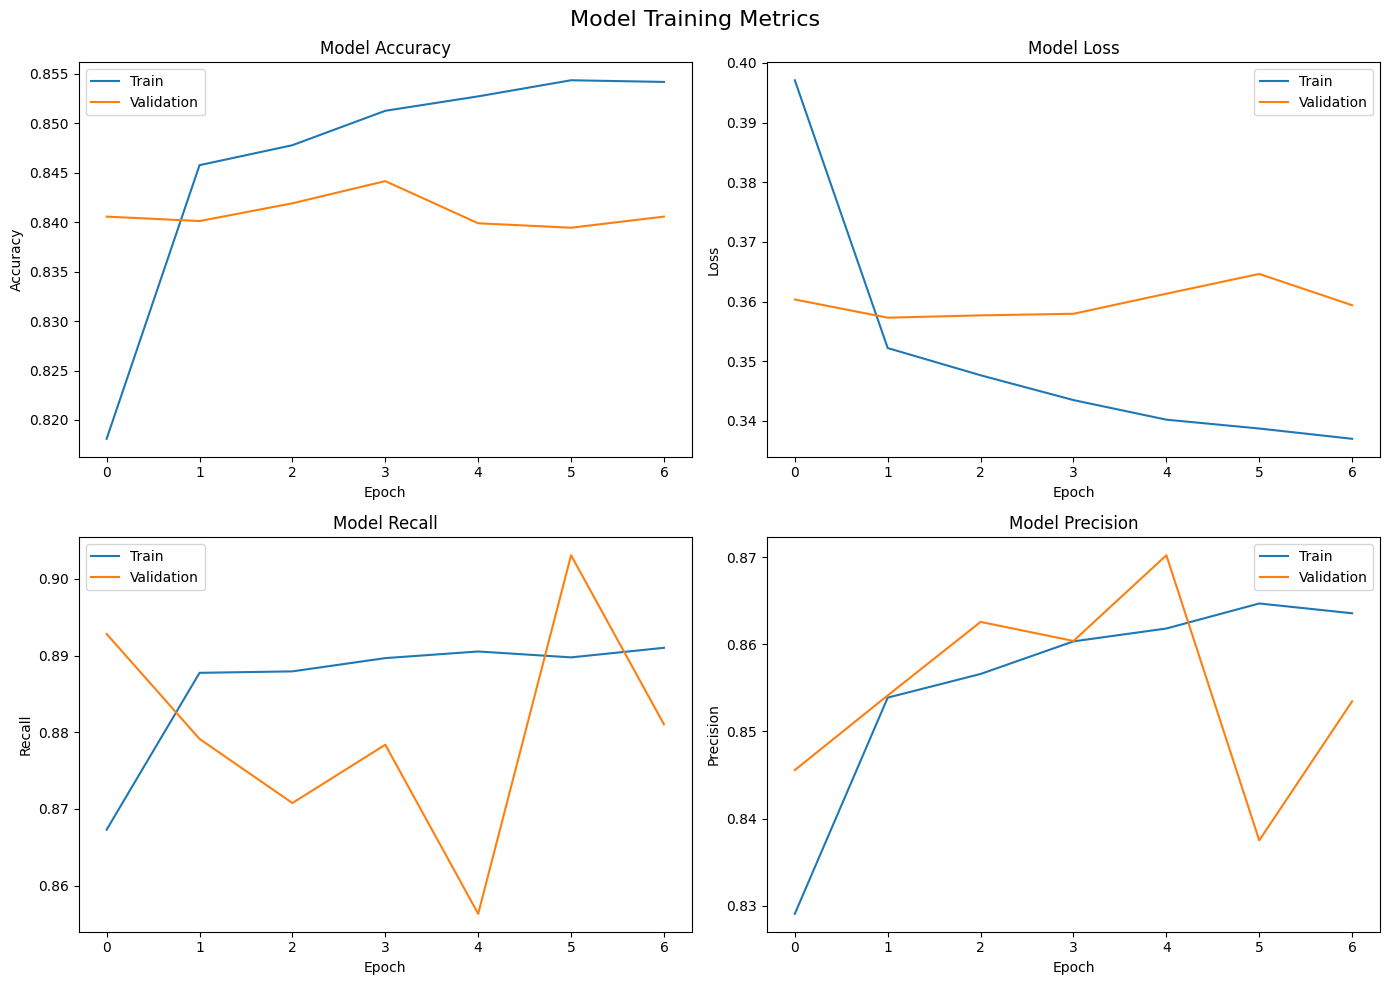

In [82]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
axes[0, 0].plot(history.history['accuracy'],     label='Train')
axes[0, 0].plot(history.history['val_accuracy'], label='Validation')
axes[0, 0].set_title('Model Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()

# Loss
axes[0, 1].plot(history.history['loss'],     label='Train')
axes[0, 1].plot(history.history['val_loss'], label='Validation')
axes[0, 1].set_title('Model Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()

# Recall
axes[1, 0].plot(history.history['recall'],     label='Train')
axes[1, 0].plot(history.history['val_recall'], label='Validation')
axes[1, 0].set_title('Model Recall')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].legend()
axes[1, 1].plot(history.history['precision'],     label='Train')
axes[1, 1].plot(history.history['val_precision'], label='Validation')
axes[1, 1].set_title('Model Precision')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].legend()

plt.suptitle('Model Training Metrics', fontsize=16)
plt.tight_layout()
plt.savefig('./assets/training_metrics.png')
plt.show()

697/697 ━━━━━━━━━━━━━━━━━━━━ 0s 181us/step


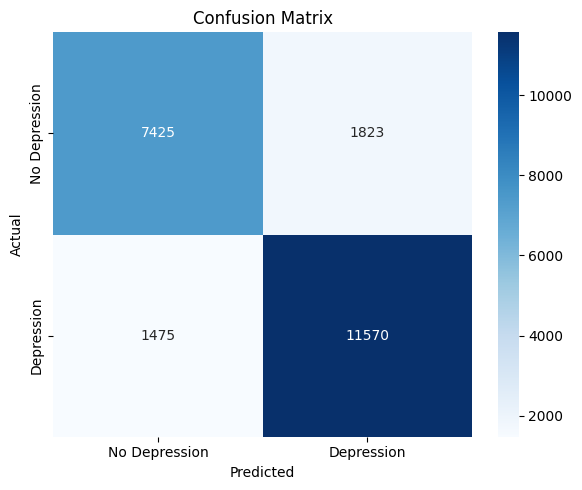

In [83]:
y_pred = (model.predict(X) > 0.5).astype(int)
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Depression', 'Depression'],
            yticklabels=['No Depression', 'Depression'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('./assets/confusion_matrix.png')
plt.show()

In [84]:
y_pred = (model.predict(X) > 0.5).astype(int)

report = classification_report(y, y_pred, target_names=['No Depression', 'Depression'])
print(report)

697/697 ━━━━━━━━━━━━━━━━━━━━ 0s 163us/step
               precision    recall  f1-score   support

No Depression       0.83      0.80      0.82      9248
   Depression       0.86      0.89      0.88     13045

     accuracy                           0.85     22293
    macro avg       0.85      0.84      0.85     22293
 weighted avg       0.85      0.85      0.85     22293

